In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path("dataset")

def load_ecobici_data(base_path=BASE_DIR):
    files = sorted(base_path.glob("[0-9][0-9][0-9][0-9]-*.csv"))
    dfs = []
    for f in files:
        print(f"→ Loading {f.name}…")
        df = pd.read_csv(f, encoding='latin-1')
        dfs.append(df)
    data = pd.concat(dfs, ignore_index=True)
    print(f"Loaded {len(data):,} rows from {len(files)} files.")
    return data

def preprocess(df):
    # Convertir a datetime (dayfirst=True) y eliminar sólo filas con fechas totalmente inválidas
    df['Fecha_Hora_Retiro'] = pd.to_datetime(df['Fecha_Retiro'] + ' ' + df['Hora_Retiro'],
                                             dayfirst=True, errors='coerce')
    df['Fecha_Hora_Arribo'] = pd.to_datetime(df['Fecha_Arribo'] + ' ' + df['Hora_Arribo'],
                                             dayfirst=True, errors='coerce')
    df = df.dropna(subset=['Fecha_Hora_Retiro','Fecha_Hora_Arribo'])

    # Calcular duración en minutos
    df['Duracion_Minutos'] = (df['Fecha_Hora_Arribo'] - df['Fecha_Hora_Retiro']).dt.total_seconds()/60

    # Filtrar trip durations realistas (>=1 min, <=720 min = 12 horas)
    df = df.query("Duracion_Minutos >= 1 & Duracion_Minutos <= 720")

    # Edad razonable: entre 10 y 100 años
    df['Edad_Usuario'] = pd.to_numeric(df['Edad_Usuario'], errors='coerce')
    df = df.query("10 <= Edad_Usuario <= 100")
    df['Edad_Usuario'] = df['Edad_Usuario'].astype(int)

    # Genero codificado: M=0, F=1, Otro=2
    df['Genero_Cod'] = df['Genero_Usuario'].map({'M':0,'F':1}).fillna(2).astype(int)

    # Limpieza de estaciones: rellenar NA con la moda
    for col in ['Ciclo_Estacion_Retiro','Ciclo_EstacionArribo']:
        tmp = pd.to_numeric(df[col], errors='coerce')
        df[col] = tmp.fillna(tmp.mode().iat[0]).astype('Int64')

    # Eliminar duplicados exactos
    df = df.drop_duplicates()

    print(f"After cleaning: {len(df):,} rows remain.")
    return df

if __name__ == "__main__":
    df = load_ecobici_data()
    df_clean = preprocess(df)
    df_clean.to_csv("ecobici.csv", index=False)
    print("Saved → ecobici.csv")




→ Loading 2024-09.csv…
→ Loading 2024-10.csv…
→ Loading 2024-11.csv…
→ Loading 2024-12.csv…
→ Loading 2025-01.csv…
→ Loading 2025-02.csv…
Loaded 11,085,307 rows from 6 files.


C:\Users\Paco\AppData\Local\Temp\ipykernel_10896\518820993.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Edad_Usuario'] = pd.to_numeric(df['Edad_Usuario'], errors='coerce')
C:\Users\Paco\AppData\Local\Temp\ipykernel_10896\518820993.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Edad_Usuario'] = df['Edad_Usuario'].astype(int)
C:\Users\Paco\AppData\Local\Temp\ipykernel_10896\518820993.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

After cleaning: 11,082,460 rows remain.
Saved → ecobici.csv


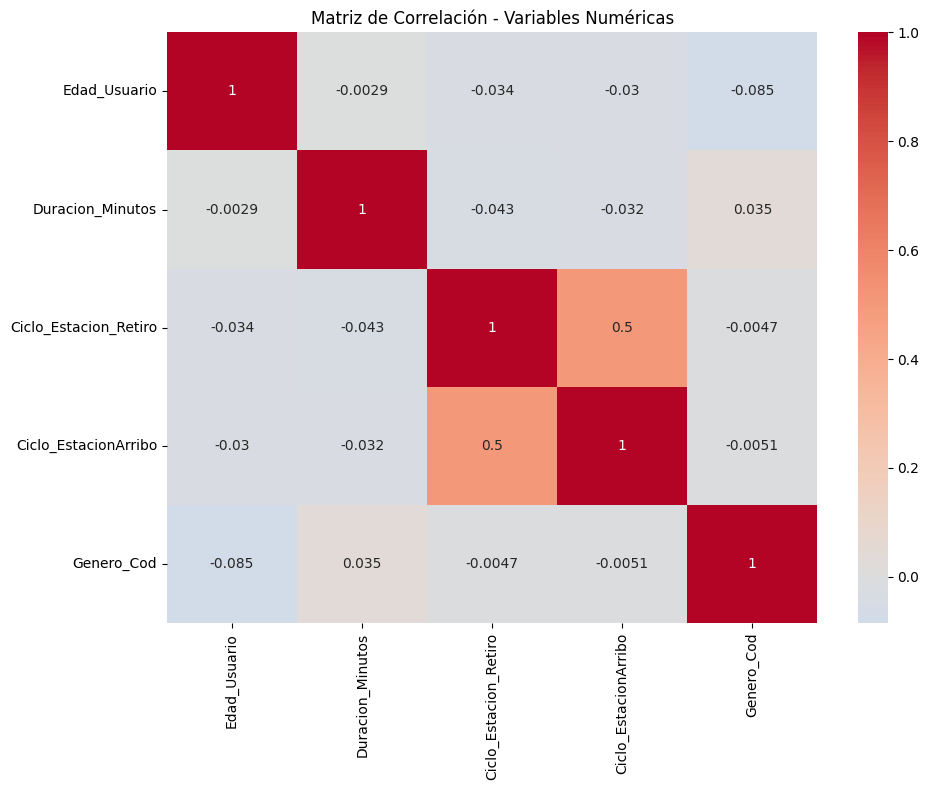

Matriz de Correlación:
                        Edad_Usuario  Duracion_Minutos  Ciclo_Estacion_Retiro  \
Edad_Usuario               1.000000         -0.002890              -0.034125   
Duracion_Minutos          -0.002890          1.000000              -0.042943   
Ciclo_Estacion_Retiro     -0.034125         -0.042943               1.000000   
Ciclo_EstacionArribo      -0.029754         -0.032415               0.503196   
Genero_Cod                -0.084837          0.034521              -0.004691   

                       Ciclo_EstacionArribo  Genero_Cod  
Edad_Usuario                      -0.029754   -0.084837  
Duracion_Minutos                  -0.032415    0.034521  
Ciclo_Estacion_Retiro              0.503196   -0.004691  
Ciclo_EstacionArribo               1.000000   -0.005142  
Genero_Cod                        -0.005142    1.000000  


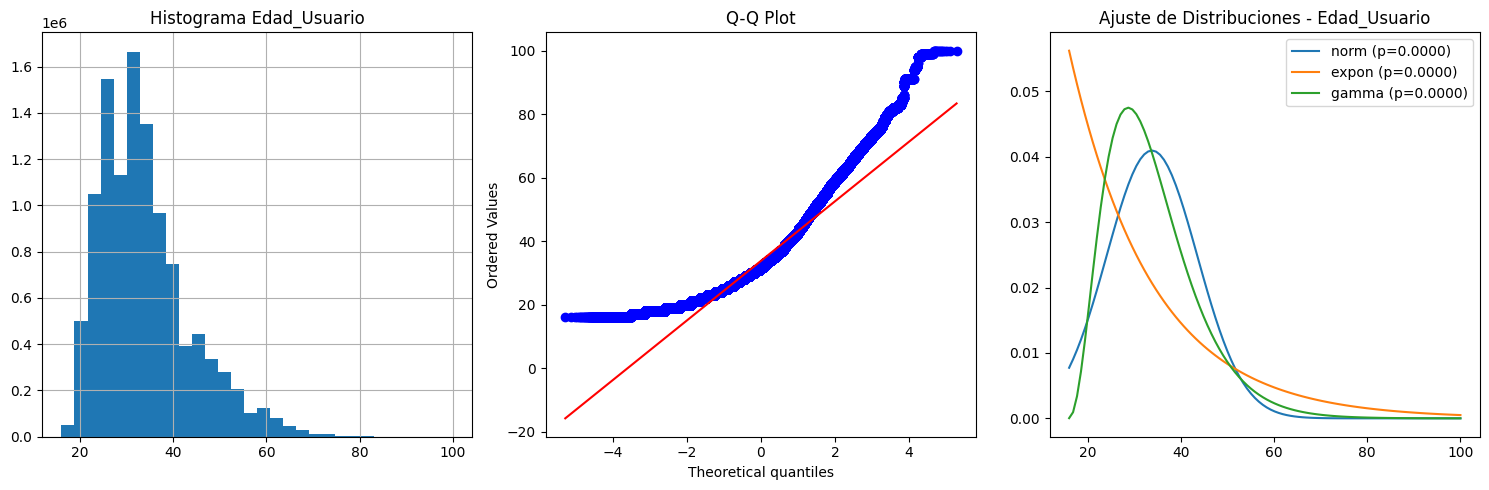

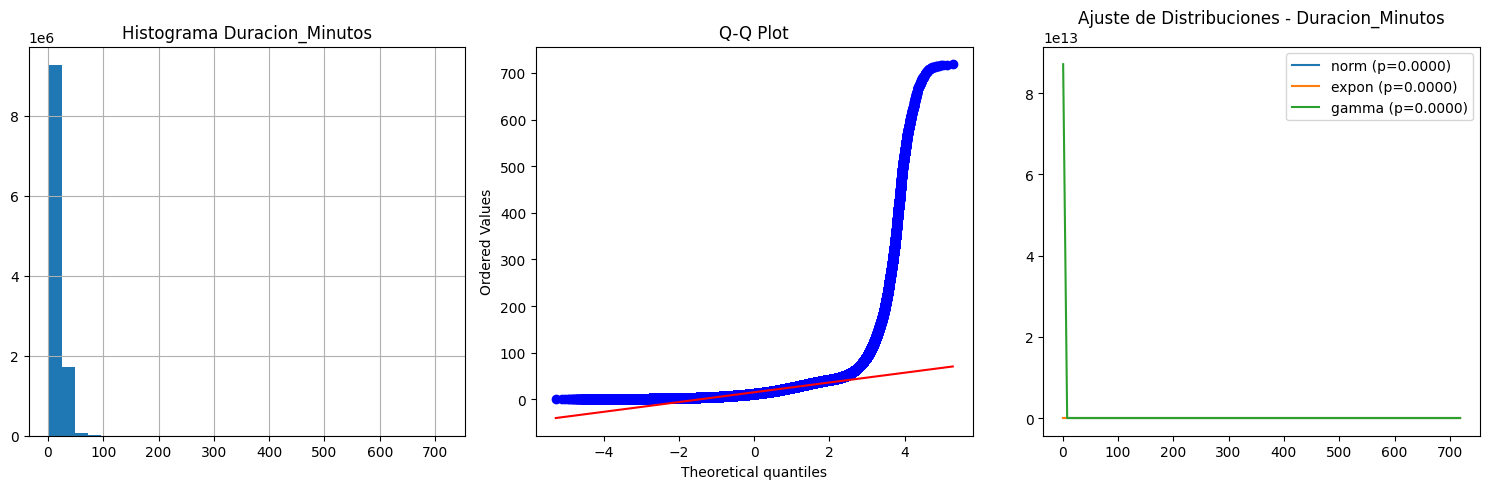


Resultados de Ajuste de Distribuciones:
Edad_Usuario: Best Distribution = gamma
Duracion_Minutos: Best Distribution = expon


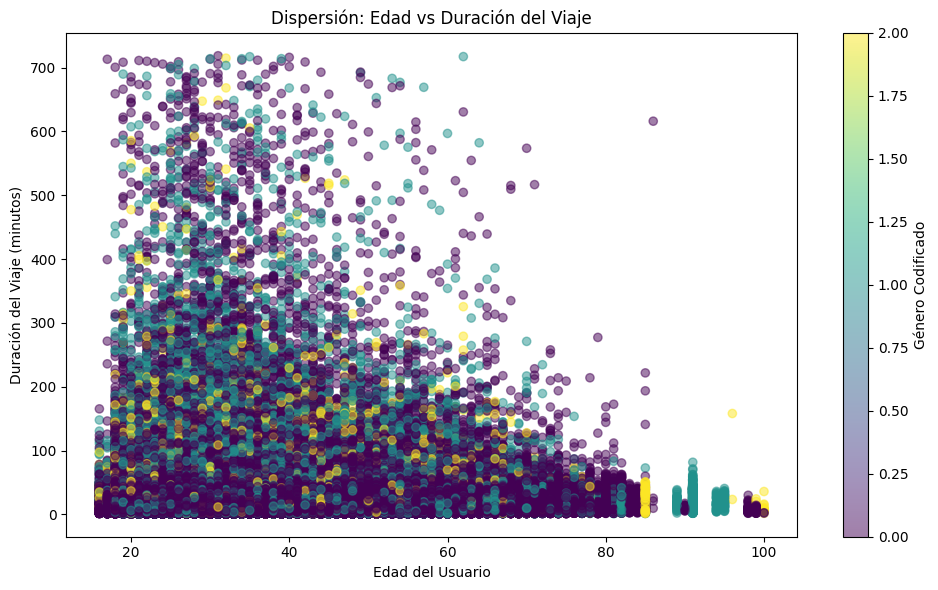

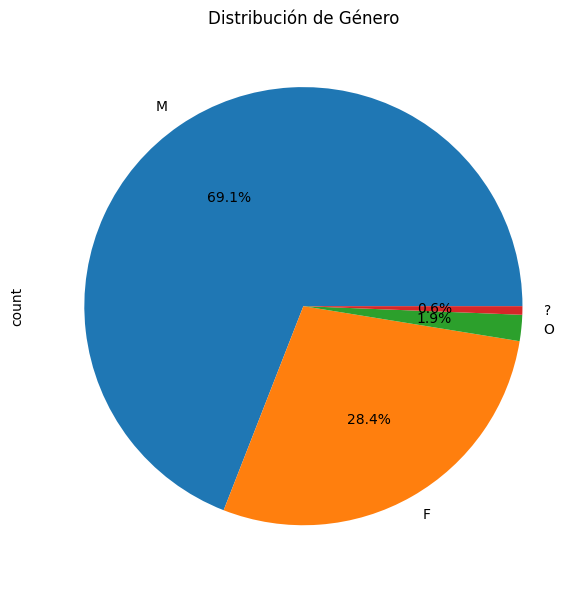

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargar datos previamente procesados
def load_processed_data(filepath='ecobici.csv'):
    df = pd.read_csv(filepath)
    return df

# Análisis de Correlación
def correlation_analysis(df):
    # Seleccionar variables numéricas
    numeric_cols = ['Edad_Usuario', 'Duracion_Minutos', 
                    'Ciclo_Estacion_Retiro', 'Ciclo_EstacionArribo', 
                    'Genero_Cod']
    
    # Crear matriz de correlación
    correlation_matrix = df[numeric_cols].corr()
    
    # Visualización de la matriz de correlación
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Matriz de Correlación - Variables Numéricas')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    return correlation_matrix

# Análisis de Distribuciones
def distribution_analysis(df):
    # Distribuciones a analizar
    distributions = {
        'Edad_Usuario': [stats.norm, stats.expon, stats.gamma],
        'Duracion_Minutos': [stats.norm, stats.expon, stats.gamma]
    }
    
    results = {}
    
    for column, dist_list in distributions.items():
        data = df[column].dropna()
        best_dist = None
        best_kstest = float('inf')
        
        plt.figure(figsize=(15, 5))
        
        # Histograma original
        plt.subplot(131)
        data.hist(bins=30)
        plt.title(f'Histograma {column}')
        
        # Q-Q Plot y pruebas de bondad de ajuste
        plt.subplot(132)
        stats.probplot(data, dist=stats.norm, plot=plt)
        plt.title('Q-Q Plot')
        
        # Comparación de distribuciones
        plt.subplot(133)
        for dist in dist_list:
            params = dist.fit(data)
            # Test de Kolmogorov-Smirnov
            kstest_result = stats.kstest(data, dist.name, params)
            
            if kstest_result.statistic < best_kstest:
                best_dist = dist
                best_kstest = kstest_result.statistic
            
            # Graficar distribución ajustada
            x = np.linspace(data.min(), data.max(), 100)
            pdf = dist.pdf(x, *params[:-2], loc=params[-2], scale=params[-1])
            plt.plot(x, pdf, label=f'{dist.name} (p={kstest_result.pvalue:.4f})')
        
        plt.title(f'Ajuste de Distribuciones - {column}')
        plt.legend()
        plt.tight_layout()
        plt.show()
        plt.close()
        
        results[column] = {
            'best_distribution': best_dist.name,
            'ks_statistic': best_kstest
        }
    
    return results

# Visualizaciones Avanzadas
def advanced_visualizations(df):
    # Diagrama de dispersión: Edad vs Duración del Viaje
    plt.figure(figsize=(10, 6))
    plt.scatter(df['Edad_Usuario'], df['Duracion_Minutos'], 
                c=df['Genero_Cod'], cmap='viridis', alpha=0.5)
    plt.colorbar(label='Género Codificado')
    plt.xlabel('Edad del Usuario')
    plt.ylabel('Duración del Viaje (minutos)')
    plt.title('Dispersión: Edad vs Duración del Viaje')
    plt.tight_layout()
    plt.show()
    plt.close()
    
    # Distribución de Género
    plt.figure(figsize=(8, 6))
    df['Genero_Usuario'].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title('Distribución de Género')
    plt.tight_layout()
    plt.show()
    plt.close()

def main():
    # Cargar datos
    df = load_processed_data()
    
    # Análisis de Correlación
    correlation_matrix = correlation_analysis(df)
    print("Matriz de Correlación:\n", correlation_matrix)
    
    # Análisis de Distribuciones
    dist_results = distribution_analysis(df)
    print("\nResultados de Ajuste de Distribuciones:")
    for col, result in dist_results.items():
        print(f"{col}: Best Distribution = {result['best_distribution']}")
    
    # Visualizaciones Avanzadas
    advanced_visualizations(df)
    

if __name__ == "__main__":
    main()


In [32]:
# %% Parte 3 — Preparación de demanda diaria
import pandas as pd

# Cargar datos limpios
df = load_processed_data()

# Convertir a datetime y agregar por día
df['Fecha_Hora_Retiro'] = pd.to_datetime(df['Fecha_Hora_Retiro'])
daily = (
    df.set_index('Fecha_Hora_Retiro')
      .resample('D')
      .size()
      .rename('y')
      .reset_index()
      .rename(columns={'Fecha_Hora_Retiro':'ds'})
)

# Opcional: agregar demanda semanal/mensual
weekly = daily.set_index('ds').resample('W')['y'].sum().reset_index()
monthly = daily.set_index('ds').resample('M')['y'].sum().reset_index()


C:\Users\Paco\AppData\Local\Temp\ipykernel_10896\2294499619.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = daily.set_index('ds').resample('M')['y'].sum().reset_index()


22:25:57 - cmdstanpy - INFO - Chain [1] start processing
22:25:57 - cmdstanpy - INFO - Chain [1] done processing


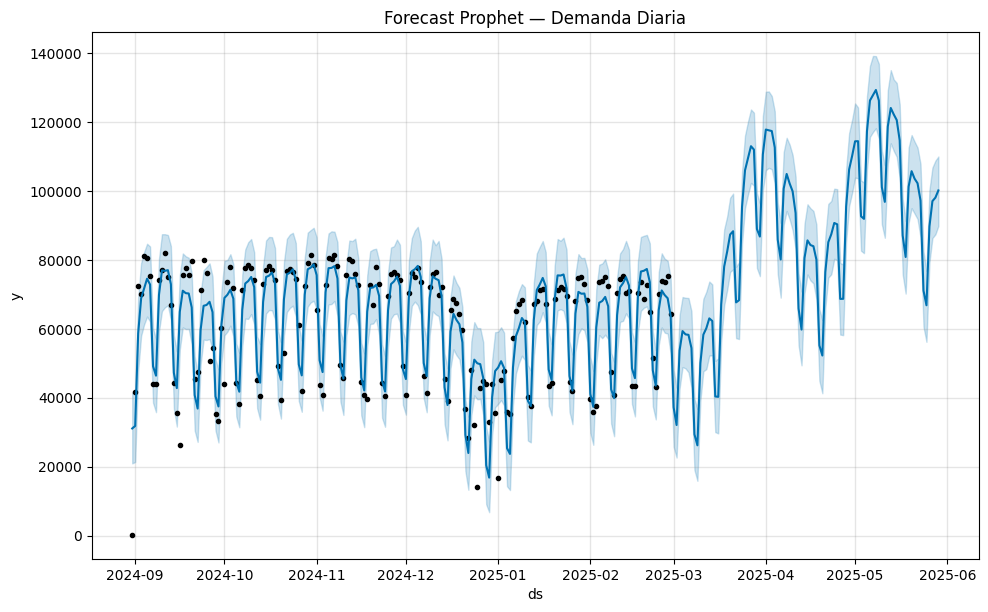

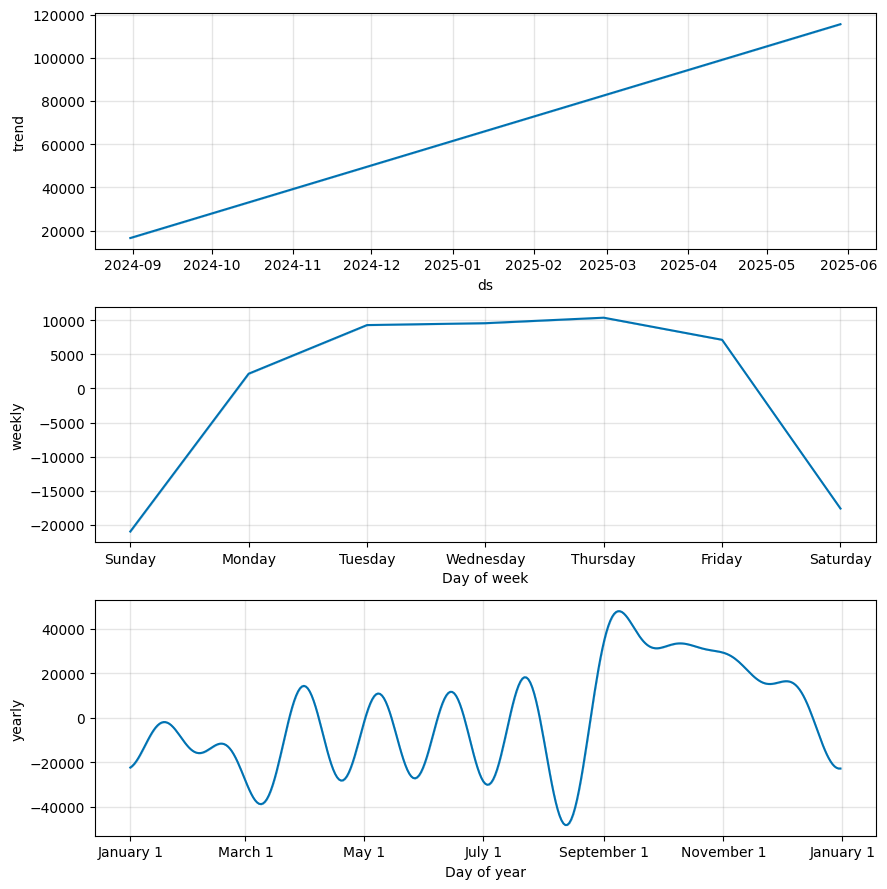

In [33]:
# %% Forecast con Prophet
from prophet import Prophet
import matplotlib.pyplot as plt

m = Prophet(yearly_seasonality=True, weekly_seasonality=True)
m.fit(daily)

future = m.make_future_dataframe(periods=90)  # próximos 90 días
forecast = m.predict(future)

m.plot(forecast); plt.title("Forecast Prophet — Demanda Diaria"); plt.show()
m.plot_components(forecast); plt.show()


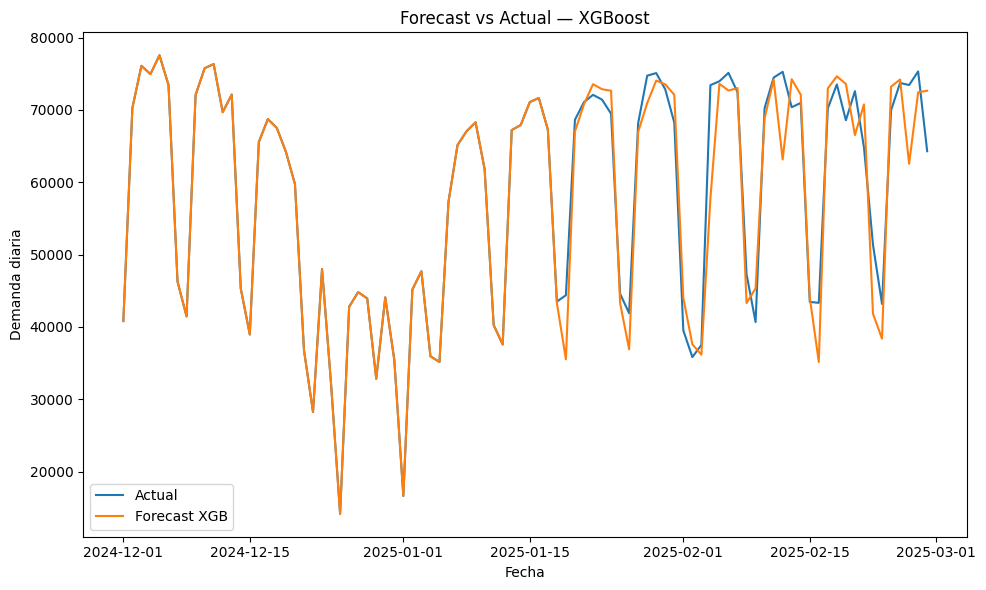

In [38]:
# %% Forecast con XGBoost
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

df_xgb = daily.copy()
df_xgb['dow'] = df_xgb['ds'].dt.dayofweek
df_xgb['month'] = df_xgb['ds'].dt.month

# Lag features
for lag in [1,7,14]:
    df_xgb[f'lag_{lag}'] = df_xgb['y'].shift(lag)

df_xgb.dropna(inplace=True)

X = df_xgb[['dow','month','lag_1','lag_7','lag_14']]
y = df_xgb['y']

tss = TimeSeriesSplit(n_splits=3)
model_xgb = XGBRegressor(n_estimators=100)
for train_idx, test_idx in tss.split(X):
    model_xgb.fit(X.iloc[train_idx], y.iloc[train_idx])

forecast_xgb = model_xgb.predict(X.tail(90))

# %% Gráfico: Predicción XGBoost vs Real (últimos 90 días)
import matplotlib.pyplot as plt

# Extraer fechas y valores reales de los últimos 90 días
ds_last90 = df_xgb['ds'].iloc[-90:]
actual_last90 = y.iloc[-90:]

plt.figure(figsize=(10, 6))
plt.plot(ds_last90, actual_last90, label='Actual')
plt.plot(ds_last90, forecast_xgb, label='Forecast XGB')
plt.xlabel('Fecha')
plt.ylabel('Demanda diaria')
plt.title('Forecast vs Actual — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()


Métricas de Modelo de Predicción de Demanda:
Mean Squared Error: 108.66
Mean Absolute Error: 6.26
R² Score: 0.92


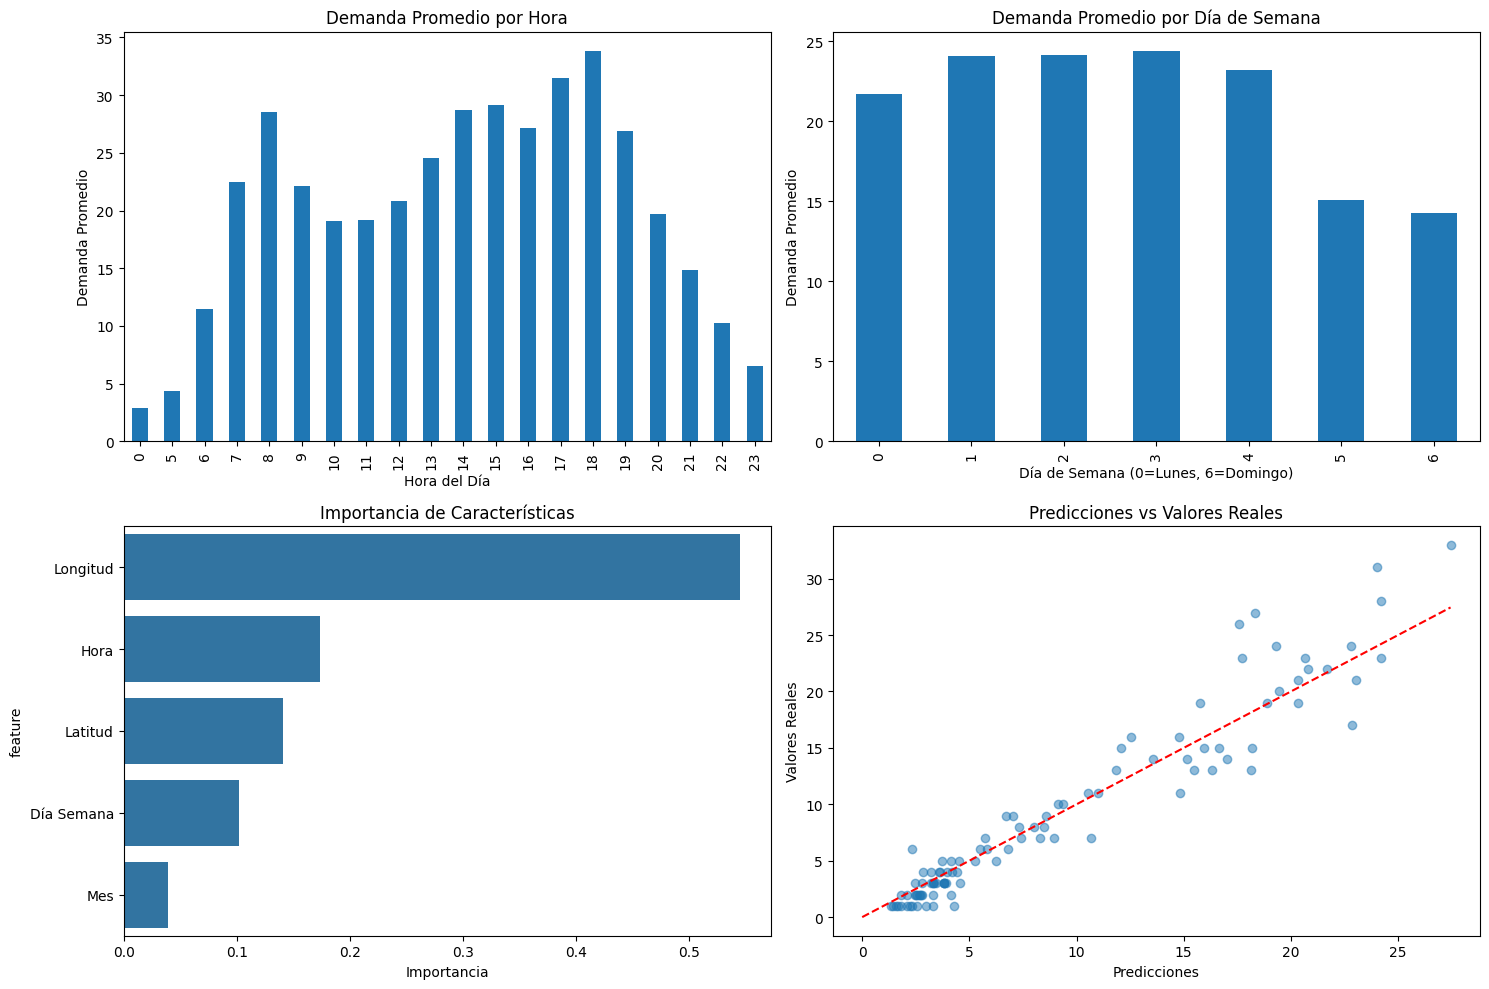

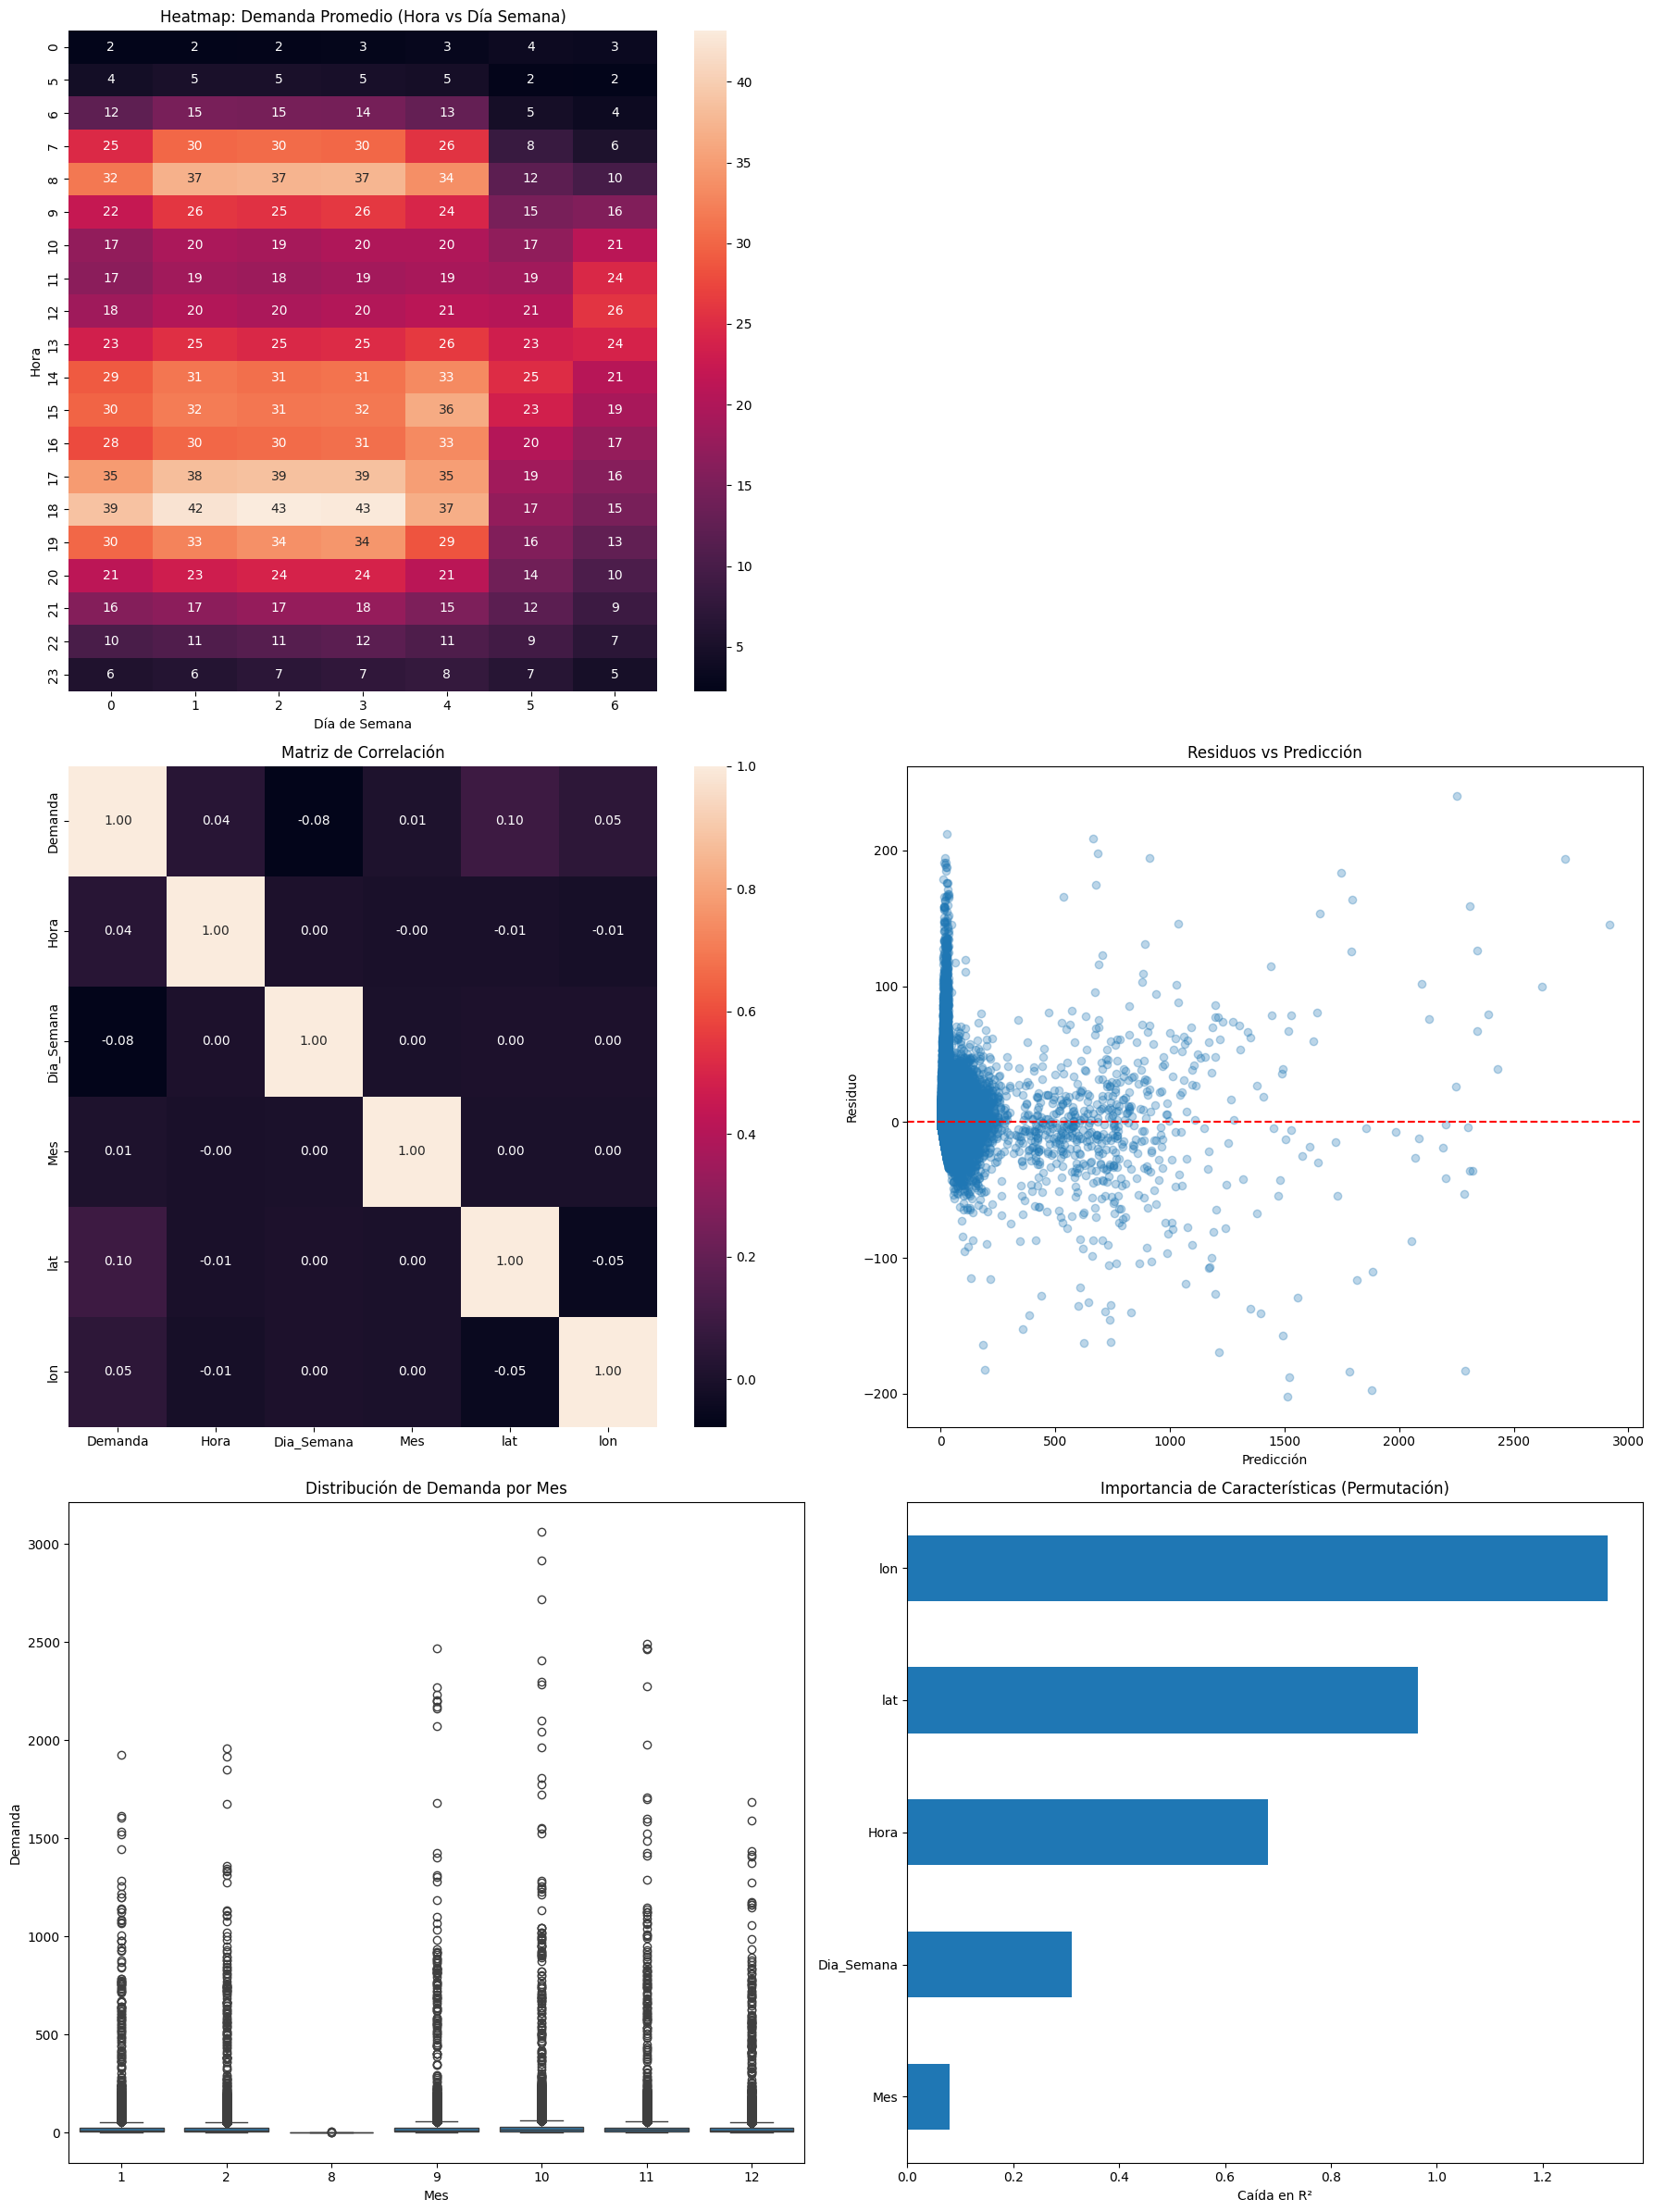

In [56]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

def load_processed_data(filepath='ecobici.csv'):
    """Cargar datos procesados"""
    df = pd.read_csv(filepath)
    return df

def prepare_demand_features(df):
    """Preparar características para predicción de demanda"""
    # Agregar características temporales
    df['Fecha_Hora_Retiro'] = pd.to_datetime(df['Fecha_Hora_Retiro'])
    
    # Extraer características temporales
    df['Hora'] = df['Fecha_Hora_Retiro'].dt.hour
    df['Dia_Semana'] = df['Fecha_Hora_Retiro'].dt.dayofweek
    df['Mes'] = df['Fecha_Hora_Retiro'].dt.month
    
    # Contar demanda por estación y hora
    demand_by_station_hour = df.groupby([
        'Ciclo_Estacion_Retiro', 
        'Hora', 
        'Dia_Semana', 
        'Mes'
    ]).size().reset_index(name='Demanda')
    
    return demand_by_station_hour

def load_stations(filepath='dataset/stations.csv'):
    """Cargar datos de estaciones"""
    stations = pd.read_csv(filepath)
    return stations

def merge_station_data(demand_df, stations_df):
    """Combinar datos de demanda con información de estaciones"""
    merged_df = demand_df.merge(
        stations_df, 
        left_on='Ciclo_Estacion_Retiro', 
        right_on='id', 
        how='left'
    )
    return merged_df

def train_demand_prediction_model(df):
    """Entrenar modelo de predicción de demanda"""
    # Preparar características para el modelo
    features = [
        'Hora', 
        'Dia_Semana', 
        'Mes', 
        'lat', 
        'lon'
    ]
    
    X = df[features]
    y = df['Demanda']
    
    # Dividir datos
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Escalar características
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Entrenar Random Forest
    rf_model = RandomForestRegressor(
        n_estimators=100, 
        random_state=42
    )
    rf_model.fit(X_train_scaled, y_train)
    
    # Predecir y evaluar
    y_pred = rf_model.predict(X_test_scaled)
    
    # Métricas de evaluación
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print("Métricas de Modelo de Predicción de Demanda:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"R² Score: {r2:.2f}")
    
    return rf_model, scaler

def visualize_demand_predictions(df, model, scaler):
    """Visualizar predicciones de demanda"""
    # Crear gráficos de predicción de demanda
    plt.figure(figsize=(15, 10))
    
    # Gráfico 1: Demanda por Hora
    plt.subplot(2, 2, 1)
    hourly_demand = df.groupby('Hora')['Demanda'].mean()
    hourly_demand.plot(kind='bar')
    plt.title('Demanda Promedio por Hora')
    plt.xlabel('Hora del Día')
    plt.ylabel('Demanda Promedio')
    
    # Gráfico 2: Demanda por Día de Semana
    plt.subplot(2, 2, 2)
    daily_demand = df.groupby('Dia_Semana')['Demanda'].mean()
    daily_demand.plot(kind='bar')
    plt.title('Demanda Promedio por Día de Semana')
    plt.xlabel('Día de Semana (0=Lunes, 6=Domingo)')
    plt.ylabel('Demanda Promedio')
    
    # Gráfico 3: Importancia de Características
    plt.subplot(2, 2, 3)
    feature_importance = pd.DataFrame({
        'feature': ['Hora', 'Día Semana', 'Mes', 'Latitud', 'Longitud'],
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    sns.barplot(x='importance', y='feature', data=feature_importance)
    plt.title('Importancia de Características')
    plt.xlabel('Importancia')
    
    # Gráfico 4: Predicciones vs Valores Reales
    plt.subplot(2, 2, 4)
    X_test = scaler.transform(df.head(100)[['Hora', 'Dia_Semana', 'Mes', 'lat', 'lon']])
    y_pred = model.predict(X_test)
    
    plt.scatter(y_pred, df.head(100)['Demanda'], alpha=0.5)
    plt.plot([0, max(y_pred)], [0, max(y_pred)], 'r--')
    plt.title('Predicciones vs Valores Reales')
    plt.xlabel('Predicciones')
    plt.ylabel('Valores Reales')
    
    plt.tight_layout()
    plt.show()

        # Preparar predicciones sobre todo el dataset para comparativas
    X = df[['Hora','Dia_Semana','Mes','lat','lon']]
    y_true = df['Demanda']
    y_pred = model.predict(scaler.transform(X))

    plt.figure(figsize=(18,24))

    # 1️⃣ Heatmap: Hora vs Día de Semana (promedio de demanda)
    plt.subplot(3,2,1)
    pivot = df.pivot_table(index='Hora', columns='Dia_Semana', values='Demanda', aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt=".0f")
    plt.title('Heatmap: Demanda Promedio (Hora vs Día Semana)')
    plt.xlabel('Día de Semana')
    plt.ylabel('Hora')

    # 3️⃣ Correlation Matrix
    plt.subplot(3,2,3)
    corr = df[['Demanda','Hora','Dia_Semana','Mes','lat','lon']].corr()
    sns.heatmap(corr, annot=True, fmt=".2f")
    plt.title('Matriz de Correlación')

    # 4️⃣ Residuals vs Predicción
    plt.subplot(3,2,4)
    residuos = y_true - y_pred
    plt.scatter(y_pred, residuos, alpha=0.3)
    plt.axhline(0, color='r', linestyle='--')
    plt.title('Residuos vs Predicción')
    plt.xlabel('Predicción')
    plt.ylabel('Residuo')

    # 5️⃣ Boxplot de Demanda por Mes
    plt.subplot(3,2,5)
    sns.boxplot(x='Mes', y='Demanda', data=df)
    plt.title('Distribución de Demanda por Mes')
    plt.xlabel('Mes')
    plt.ylabel('Demanda')

    # 6️⃣ Feature Importance (permutation importance)
    from sklearn.inspection import permutation_importance
    perm = permutation_importance(model, scaler.transform(X), y_true, n_repeats=5, random_state=42)
    feat_imp = pd.Series(perm.importances_mean, index=['Hora','Dia_Semana','Mes','lat','lon']).sort_values()
    plt.subplot(3,2,6)
    feat_imp.plot(kind='barh')
    plt.title('Importancia de Características (Permutación)')
    plt.xlabel('Caída en R²')

    plt.tight_layout()
    plt.show()

def main():
    # Cargar datos procesados
    df = load_processed_data()
    
    # Preparar características de demanda
    demand_df = prepare_demand_features(df)
    
    # Cargar datos de estaciones
    stations_df = load_stations()
    
    # Combinar datos de demanda con información de estaciones
    merged_df = merge_station_data(demand_df, stations_df)
    
    # Entrenar modelo de predicción de demanda
    model, scaler = train_demand_prediction_model(merged_df)
    
    # Visualizar predicciones
    visualize_demand_predictions(merged_df, model, scaler)
    

if __name__ == "__main__":
    main()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, NMF
from sklearn.manifold import MDS, TSNE, Isomap
from sklearn.cluster import KMeans
import math

# -- Utility Functions --
def load_data():
    df = pd.read_csv('ecobici.csv', parse_dates=['Fecha_Hora_Retiro','Fecha_Hora_Arribo'])
    stations = pd.read_csv('dataset/stations.csv')
    return df, stations

def merge_stations(df, stations):
    stations = stations.rename(columns={'id':'Ciclo_Estacion','lat':'lat','lon':'lon'})
    df = df.merge(stations.add_suffix('_retiro'), left_on='Ciclo_Estacion_Retiro', right_on='Ciclo_Estacion_retiro', how='left')
    df = df.merge(stations.add_suffix('_arribo'), left_on='Ciclo_EstacionArribo', right_on='Ciclo_Estacion_arribo', how='left')
    return df

def haversine(lon1, lat1, lon2, lat2):
    R = 6371  # Earth radius in km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

def add_distance(df):
    df['Distance_km'] = haversine(df['lon_retiro'], df['lat_retiro'], df['lon_arribo'], df['lat_arribo'])
    return df

# -- Dimensionality Reduction & Clustering --
def pca_analysis(df):
    features = ['Edad_Usuario','Duracion_Minutos','Distance_km']
    X = StandardScaler().fit_transform(df[features].dropna())
    pcs = PCA(n_components=2, random_state=42).fit_transform(X)
    plt.figure(); plt.scatter(pcs[:,0], pcs[:,1], alpha=0.4); plt.title('PCA of Trip Features'); plt.xlabel('PC1'); plt.ylabel('PC2'); plt.savefig('pca_trips.png'); plt.close()

def kmeans_clustering(df):
    features = ['Edad_Usuario','Duracion_Minutos','Distance_km']
    X = StandardScaler().fit_transform(df[features].dropna())
    labels = KMeans(n_clusters=4, random_state=42).fit_predict(X)
    plt.figure(); plt.scatter(X[:,0], X[:,1], c=labels, alpha=0.4); plt.title('KMeans Clusters'); plt.savefig('kmeans_trips.png'); plt.close()

def mds_stations(df):
    pivot = df.groupby(['Ciclo_Estacion_Retiro','Ciclo_EstacionArribo']).size().unstack(fill_value=0)
    coords = MDS(n_components=2, random_state=42).fit_transform(pivot)
    plt.figure(); plt.scatter(coords[:,0], coords[:,1], alpha=0.5); plt.title('MDS of Station Usage'); plt.savefig('mds_stations.png'); plt.close()

def tsne_analysis(df):
    features = ['Edad_Usuario','Duracion_Minutos','Distance_km']
    X = StandardScaler().fit_transform(df[features].dropna())
    emb = TSNE(n_components=2, random_state=42, perplexity=50).fit_transform(X)
    plt.figure(); plt.scatter(emb[:,0], emb[:,1], alpha=0.4); plt.title('t-SNE of Trip Features'); plt.savefig('tsne_trips.png'); plt.close()

def isomap_analysis(df):
    features = ['Edad_Usuario','Duracion_Minutos','Distance_km']
    X = StandardScaler().fit_transform(df[features].dropna())
    embedding = Isomap(n_components=2).fit_transform(X)
    plt.figure(); plt.scatter(embedding[:,0], embedding[:,1], alpha=0.4); plt.title('Isomap of Trip Features'); plt.savefig('isomap_trips.png'); plt.close()

def nmf_station(df):
    pivot = df.groupby(['Ciclo_Estacion_Retiro','Ciclo_EstacionArribo']).size().unstack(fill_value=0)
    W = NMF(n_components=5, random_state=42).fit_transform(pivot)
    return W

# -- Temporal Analysis --
def daily_time_series(df):
    df['date'] = df['Fecha_Hora_Retiro'].dt.date
    daily_counts = df.groupby('date').size()
    plt.figure(); daily_counts.plot(); plt.title('Daily Trip Counts'); plt.savefig('daily_counts.png'); plt.close()

# -- Main Execution --
def main():
    df, stations = load_data()
    df = merge_stations(df, stations)
    df = add_distance(df)
    pca_analysis(df)
    kmeans_clustering(df)
    mds_stations(df)
    tsne_analysis(df)
    isomap_analysis(df)
    nmf_station(df)
    daily_time_series(df)
    print('Analysis complete. Plots saved to disk.')

if __name__ == '__main__':
    main()

c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\sklearn\manifold\_mds.py:632: UserWarning: The MDS API has changed. ``fit`` now constructs an dissimilarity matrix from data. To use a custom dissimilarity matrix, set ``dissimilarity='precomputed'``.
  warnings.warn(


In [2]:
import matplotlib.pyplot as plt

def visualize_outliers(df):
    numeric_cols = ['Edad_Usuario', 'Duracion_Minutos']
    
    for col in numeric_cols:
        data = df[col].dropna()
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Boxplot
        plt.figure(figsize=(8, 4))
        plt.boxplot(data, vert=False)
        plt.title(f'Boxplot de {col}')
        plt.xlabel(col)
        plt.show()
        plt.close()

        # Histograma con límites de outliers
        plt.figure(figsize=(8, 4))
        plt.hist(data, bins=50)
        plt.axvline(lower_bound, linestyle='--')
        plt.axvline(upper_bound, linestyle='--')
        plt.title(f'Histograma de {col} (límites de outliers)')
        plt.xlabel(col)
        plt.show()
        plt.close()

    # Scatter Edad vs Duración resaltando outliers de Duración
    df_clean = df.dropna(subset=['Edad_Usuario', 'Duracion_Minutos'])
    Q1 = df_clean['Duracion_Minutos'].quantile(0.25)
    Q3 = df_clean['Duracion_Minutos'].quantile(0.75)
    IQR = Q3 - Q1
    lb = Q1 - 1.5 * IQR
    ub = Q3 + 1.5 * IQR
    mask = (df_clean['Duracion_Minutos'] < lb) | (df_clean['Duracion_Minutos'] > ub)

    plt.figure(figsize=(8, 6))
    plt.scatter(df_clean['Edad_Usuario'], df_clean['Duracion_Minutos'], alpha=0.3)
    plt.scatter(df_clean.loc[mask, 'Edad_Usuario'], df_clean.loc[mask, 'Duracion_Minutos'], marker='o')
    plt.title('Outliers en Duración vs Edad')
    plt.xlabel('Edad del Usuario')
    plt.ylabel('Duración del Viaje (minutos)')
    plt.show()
    plt.close()

In [ ]:
# %%
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

def load_processed_data(filepath='ecobici.csv'):
    df = pd.read_csv(filepath)
    return df

def user_clustering(df, n_clusters=4):
    # Selección de variables relevantes
    features = ['Edad_Usuario', 'Duracion_Minutos', 'Genero_Cod']
    X = df[features].copy()
    
    # Escalamiento de datos
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # PCA para visualización (2 componentes)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # KMeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    clusters = kmeans.fit_predict(X_scaled)
    
    # Añadir etiquetas al dataframe
    df_clustered = df.copy()
    df_clustered['Cluster_Usuario'] = clusters
    
    # Visualización
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='tab10', alpha=0.7)
    plt.title(f'Clustering de Usuarios ECOBICI (K={n_clusters}) - PCA')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.show()
    
    # Centroides (opcional)
    print("Centroides del modelo (en espacio original escalado):")
    print(pd.DataFrame(kmeans.cluster_centers_, columns=features))
    
    return df_clustered

def main():
    df = load_processed_data()
    df_clustered = user_clustering(df, n_clusters=4)
    df_clustered.to_csv("ecobici_clustered.csv", index=False)
    print("Archivo guardado → ecobici_clustered.csv")

if __name__ == "__main__":
    main()


C:\Users\Paco\AppData\Local\Temp\ipykernel_30732\2065185920.py:42: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Paco\anaconda3\envs\Machine_Learning_Models\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)
